# Multi-modal RAG (reference implementation)


In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

ROOT = Path.cwd().parent                      # .../SAIT  (running from notebooks/)
load_dotenv(ROOT / 'data' / '.env', override=True)

assert os.getenv('OPENAI_API_KEY'), 'OPENAI_API_KEY not loaded — check the .env path'
print('key loaded')

key loaded


## Extract the data

### Partition PDF tables, text, and images

In [2]:
from unstructured.partition.pdf import partition_pdf
import glob

DATA = ROOT / 'data'
pdfs = sorted(glob.glob(str(DATA / '*.pdf')))
file_path = pdfs[0]                            # start with ONE pdf; widen later
print('partitioning:', Path(file_path).name)

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy='hi_res',                     # mandatory to infer tables

    extract_image_block_types=['Image'],   # add 'Table' to also extract table images
    extract_image_block_to_payload=True,   # True => base64 in metadata (for API use)

    chunking_strategy='by_title',          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,
)
print(f'{len(chunks)} chunks')

/Users/afrahalharbi/Desktop/Imperial/Project/code/SAIT/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No languages specified, defaulting to English.


partitioning: 196a95604877d326c6586e60477b59d4_MIT6_006S20_lec9.pdf


Loading weights: 100%|██████████| 367/367 [00:00<00:00, 5804.66it/s]


3 chunks


In [3]:

set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [4]:

chunks[0].metadata.orig_elements

In [5]:
# What an extracted image looks like (base64 present because extract_image_block_to_payload=True)
elements = chunks[0].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict() if chunk_images else 'no images in chunk 0'

{'type': 'Image',
 'element_id': 'd91cabc5-4f7a-4a59-9d4c-5c30bd21ae88',
 'text': 'Go "OD OD b> 6&¥e',
 'metadata': {'detection_class_prob': 0.8153073787689209,
  'coordinates': {'points': ((np.float64(654.7699584960938),
     np.float64(2267.54248046875)),
    (np.float64(654.7699584960938), np.float64(2653.1357421875)),
    (np.float64(2479.793212890625), np.float64(2653.1357421875)),
    (np.float64(2479.793212890625), np.float64(2267.54248046875))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-06-27T14:09:42',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 1,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [17]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

pages = PyPDFLoader(file_path).load()
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = splitter.split_documents(pages)          # clean text, LangChain Documents

tables = []            # tables stay embedded in the text chunks with PyPDF
table_summaries = []

print('texts:', len(texts), '| images:', len(images))

texts: 11 | images: 2


/var/folders/hw/9rk5hsh90j51sypntxw27ss00000gn/T/ipykernel_36447/1854585527.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [7]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if 'CompositeElement' in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if 'Image' in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)
print('images:', len(images))

images: 2


#### Check what the images look like

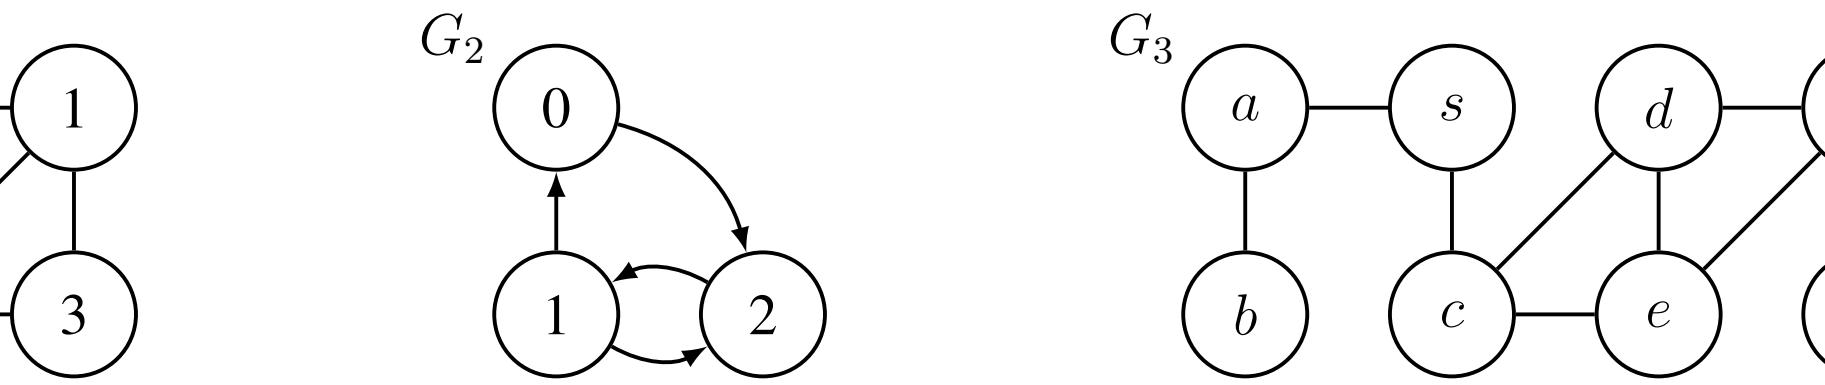

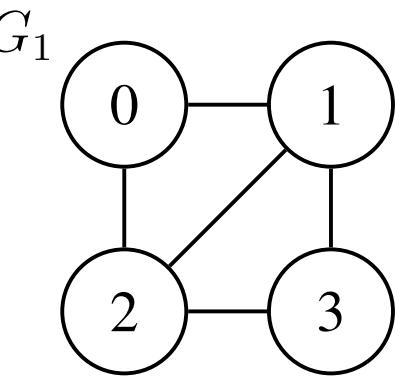

In [8]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    image_data = base64.b64decode(base64_code)
    display(Image(data=image_data))

# inspect a few — check whether the figure crops are complete or clipped
for img in images[:3]:
    display_base64_image(img)

## Summarize the data

A summary of each element is vectorized and used for retrieval; the **original** is what gets returned.

### Text and Table summaries
No multimodal model needed here — a plain text model suffices.

In [9]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# The reference uses ChatGroq (needs GROQ_API_KEY). Using OpenAI here avoids a second key;
# swap the two lines below if you want the exact Groq model.
# from langchain_groq import ChatGroq
# model = ChatGroq(temperature=0.5, model='llama-3.1-8b-instant')
model = ChatOpenAI(temperature=0.5, model='gpt-4o-mini')

summarize_chain = {'element': lambda x: x} | prompt | model | StrOutputParser()

In [10]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {'max_concurrency': 3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {'max_concurrency': 3}) if tables_html else []

print('text_summaries:', len(text_summaries), '| table_summaries:', len(table_summaries))
text_summaries[:1]

text_summaries: 3 | table_summaries: 0


["Lecture 9 of MIT's Introduction to Algorithms focuses on Breadth-First Search and introduces a new unit on Graphs. It covers the importance of graphs in various applications, such as networks and games, and defines key concepts like vertices, edges, directed and undirected edges, and simple graphs. The lecture also explains neighbor sets, out-degrees, in-degrees, and how to represent graphs using adjacency lists. A quiz is scheduled for the following week covering previous lectures on Data Structures and Sorting."]

### Image summaries
The reference uses `gpt-4o-mini`. Swap the model on the last line if you want to compare.

In [12]:
prompt_template = """Describe the image in detail. For context,
                  the image is part of a a series of lectures for introduction to algorithms."""
messages = [
    (
        'user',
        [
            {'type': 'text', 'text': prompt_template},
            {
                'type': 'image_url',
                'image_url': {'url': 'data:image/jpeg;base64,{image}'},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOpenAI(model='gpt-4o-mini') | StrOutputParser()

image_summaries = chain.batch(images)
print(len(image_summaries), 'image summaries')

2 image summaries


In [13]:
print(image_summaries[0] if image_summaries else 'no images')

The image consists of three distinct graphs, labeled \(G_1\), \(G_2\), and \(G_3\), each represented in a simple illustrative format.

1. **Graph \(G_1\)**: 
   - Contains two nodes labeled \(1\) and \(3\).
   - There is a vertical connecting edge between these two nodes.
   - Node \(1\) is positioned above node \(3\).

2. **Graph \(G_2\)**:
   - Contains three nodes labeled \(0\), \(1\), and \(2\).
   - Node \(0\) is placed at the top, with directed edges going to nodes \(1\) and \(2\).
   - Node \(1\) has a loop directed back to itself and also connects to node \(2\) through a directed edge.
   - Node \(2\) has an incoming edge from node \(1\) and an outgoing edge back to node \(1\).

3. **Graph \(G_3\)**:
   - Features five nodes labeled \(a\), \(b\), \(c\), \(d\), and \(e\).
   - Node \(a\) is positioned at the top, connected to node \(b\) directly underneath it.
   - Node \(c\) is connected from node \(b\) and has edges going to both \(s\) above it and to nodes \(d\) and \(e\).
  

## Load data and summaries to vectorstore

### Create the vectorstore

In [14]:
import uuid
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

# The vectorstore to use to index the child chunks (the SUMMARIES)
vectorstore = Chroma(collection_name='multi_modal_rag', embedding_function=OpenAIEmbeddings())

# The storage layer for the parent documents (the ORIGINALS)
store = InMemoryStore()
id_key = 'doc_id'

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

### Load the summaries and link them to the original data

In [15]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]})
    for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
if tables:
    table_ids = [str(uuid.uuid4()) for _ in tables]
    summary_tables = [
        Document(page_content=summary, metadata={id_key: table_ids[i]})
        for i, summary in enumerate(table_summaries)
    ]
    retriever.vectorstore.add_documents(summary_tables)
    retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
if images:
    img_ids = [str(uuid.uuid4()) for _ in images]
    summary_img = [
        Document(page_content=summary, metadata={id_key: img_ids[i]})
        for i, summary in enumerate(image_summaries)
    ]
    retriever.vectorstore.add_documents(summary_img)
    retriever.docstore.mset(list(zip(img_ids, images)))

print('loaded into retriever')

loaded into retriever


### Check retrieval

In [16]:
docs = retriever.invoke('show me the example graphs with vertices and edges')

for doc in docs:
    print(str(doc)[:400] + '\n\n' + '-' * 80)

/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCAGBByEDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVW

--------------------------------------------------------------------------------
Introduction to Algorithms: 6.006 Massachusetts Institute of Technology Instructors: Erik Demaine, Jason Ku, and Justin Solomon

Lecture 9: Breadth-First Search

Lecture 9: Breadth-First Search

New Unit: Graphs!

Quiz | next week covers lectures LO1 - LO8 on Data Structures and Sorting

@

Today, start new unit, lectures LO9 - L14 on Graph Algorithms

e

Graph Applications

Why? Graphs are everyw

--------------------------------------------------------------------------------
/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAA

## RAG pipeline

Retrieved **images go into the prompt**, so the answering model sees the real figure.

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception:
            text.append(doc)
    return {'images': b64, 'texts': text}


def build_prompt(kwargs):
    docs_by_type = kwargs['context']
    user_question = kwargs['question']

    context_text = ''
    if len(docs_by_type['texts']) > 0:
        for text_element in docs_by_type['texts']:
            context_text += text_element.text

    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{'type': 'text', 'text': prompt_template}]

    if len(docs_by_type['images']) > 0:
        for image in docs_by_type['images']:
            prompt_content.append(
                {
                    'type': 'image_url',
                    'image_url': {'url': f'data:image/jpeg;base64,{image}'},
                }
            )

    return ChatPromptTemplate.from_messages(
        [HumanMessage(content=prompt_content)]
    )


chain = (
    {
        'context': retriever | RunnableLambda(parse_docs),
        'question': RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model='gpt-4o')
    | StrOutputParser()
)

chain_with_sources = {
    'context': retriever | RunnableLambda(parse_docs),
    'question': RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model='gpt-4o')
        | StrOutputParser()
    )
)

print('chains built')

In [ ]:
response = chain.invoke('What is breadth-first search and what is its running time?')
print(response)

In [ ]:
# With sources — shows which text chunks and which images fed the answer
response = chain_with_sources.invoke('In the example graph G1, which vertices is vertex 1 connected to?')

print('Response:', response['response'])

print('\n\nContext:')
for text in response['context']['texts']:
    print(text.text[:300])
    print('Page number: ', text.metadata.page_number)
    print('\n' + '-' * 50 + '\n')
for image in response['context']['images']:
    display_base64_image(image)

## References

- [LangChain cookbook: Semi-structured and multi-modal RAG](https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb)
- [Multi-vector retriever](https://python.langchain.com/docs/how_to/multi_vector/)

### What to check

1. **Image crops** (the display cell) — are the figures complete, or clipped/split?
2. **The last cell** is the acid test: in G1, vertex 1 connects to **0, 2, and 3**.
   The model sees the *real image*, so if it still misses the 1–2 diagonal, the figure
   channel isn't adding reliable value over the adjacency lists already in the text.